Code to transform VIIRS MF products in SODA format

In [1]:
import pandas as pd
import glob

folder = "/home/imperatoren/work/edelweiss_assimilation/data/france/mf_snow_cover/cms/"
obs_file_list = glob.glob(f"{folder}/202*/*/*.nc")
# obs = xr.open_dataset(f"{folder}/MF_FSC_VNP_20220226.nc")
dates = pd.date_range(start="2021/08/01", end="2022/07/31", freq="D")
obs_file_list_out = []
for d in dates:
    date_obs_files = [obs_f for obs_f in obs_file_list if d.strftime("%Y%m%d") in obs_f]
    for do in date_obs_files:
        if "all" in do:
            obs_file_list_out.append(do)
            break
        elif "npp" in do:
            obs_file_list_out.append(do)
            break
        elif "noaa20" in do:
            obs_file_list_out.append(do)
            break

In [2]:
import xarray as xr


def format_coords_soda(obs: xr.Dataset) -> xr.Dataset:
    obs = obs.rename({"x": "xx", "y": "yy"})
    obs = obs.reindex(yy=obs.coords["yy"].sortby("yy"), xx=obs.coords["xx"].sortby("xx"))
    return obs


def format_viirs_soda(obs: xr.Dataset) -> xr.Dataset:
    obs = obs.isel(time=0).drop_vars("time")
    obs = obs.rename({"snow_cover_fraction": "SCF"})
    obs = format_coords_soda(obs=obs)
    obs.data_vars["SCF"].encoding["dtype"] = "float64"
    obs = obs.fillna(1e20)
    obs.data_vars["SCF"].rio.write_nodata(1e20, inplace=True)
    obs.coords["yy"].attrs["axis"] = "Y"
    obs.coords["xx"].attrs["axis"] = "X"
    obs.data_vars["SCF"].encoding["missing_value"] = 1e20
    obs.data_vars["SCF"][:] = obs.data_vars["SCF"].values / 200
    obs.data_vars["SCF"][:] = obs.data_vars["SCF"].where(obs.data_vars["SCF"] <= 1, 1e20).values
    return obs


platform_dict = {"all": "MP", "npp": "NP", "noaa20": "J1", "noaa21": "J2"}


def rename_viirs_product(filename: str):
    date, _, plat_cms = filename.split(".")[0].split("_")
    out_filename = f"MF_FSC_V{platform_dict[plat_cms]}_L3_{date}12.nc"
    return out_filename

In [5]:
from edelassim.observations import reprojection_mf_fsc_l3_to_grid, EdelweissGrandesRoussesGrid
import os

glacier_mask_fileapth = "/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses250m/auxiliary/glacier_mask/glacier_mask_glims_2022_grandesrousses.nc"
forest_mask_filepath = "/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses250m/auxiliary/forest_mask/forest_mask_corine_grandesrousses_max.nc"

glacier_mask = format_coords_soda(xr.open_dataarray(glacier_mask_fileapth, engine="rasterio")).sel(band=1).drop_vars("band")
forest_mask = format_coords_soda(xr.open_dataarray(forest_mask_filepath, engine="rasterio")).sel(band=1).drop_vars("band")
for obs_f in obs_file_list_out:
    obs_orig = xr.open_dataset(obs_f, mask_and_scale=False, engine="rasterio")
    obs_reprojected = reprojection_mf_fsc_l3_to_grid(
        meteofrance_snow_cover=obs_orig.data_vars["snow_cover_fraction"], output_grid=EdelweissGrandesRoussesGrid()
    )
    obs_soda_ready = format_viirs_soda(xr.Dataset({"snow_cover_fraction": obs_reprojected}))
    obs_soda_ready = obs_soda_ready.where(1 - glacier_mask, 1e20).where(1 - forest_mask, 1e20)
    # Test remove zeros for bertrand assimilation code problem
    # obs_soda_ready = obs_soda_ready.where(obs_soda_ready != 0, 0.01)
    out_filepath = f"/home/imperatoren/work/edelweiss_assimilation/observations/grandesrousses250m/meteofrance/soda/{rename_viirs_product(os.path.basename(obs_f))}"
    # print(out_filepath)
    obs_soda_ready.to_netcdf(out_filepath)


In [14]:
import xarray as xr
ds = xr.open_dataset('/home/imperatoren/work/edelweiss_assimilation/observations/grandesrousses250m/meteofrance/soda/MF_FSC_VJ1_L3_2022063012.nc')
ds.SCF[:] =1e20
ds.to_netcdf('/home/imperatoren/work/edelweiss_assimilation/observations/grandesrousses250m/meteofrance/soda/MF_FSC_VJ1_L3_2021080412.nc')

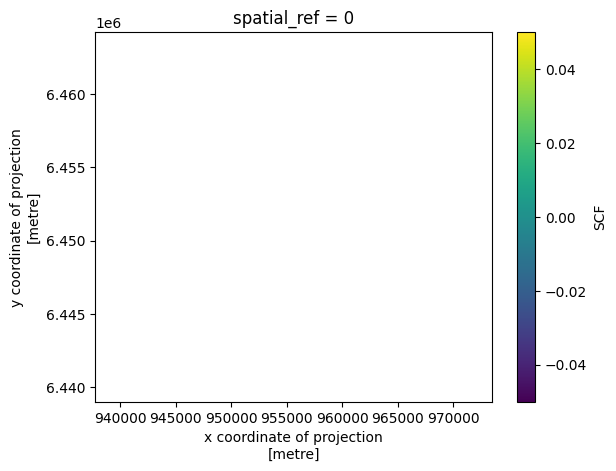

In [17]:
ds=xr.open_dataset('/home/imperatoren/work/edelweiss_assimilation/observations/grandesrousses250m/meteofrance/soda/MF_FSC_VJ1_L3_2021080212.nc')
ds.SCF.plot.imshow()